# Q1: Sequence-based vs Component-based Feature Evaluation

**Research Question:** Do sequence-based features provide a detection advantage over component-based features for DDoS detection, and does this advantage hold consistently across different real-world network environments?

**Approach:** Two feature representations are compared across the same set of models and networks:
- **Sequence-based**: The first *k* = 10 consecutive 1-second observations (components) of a DDoS event are treated as a multivariate time series, providing temporal context.
- **Component-based** (classical baseline): Each 1-second observation is classified independently, without knowledge of preceding intervals.

Both approaches are evaluated on four network datasets (SetA–SetD) drawn from the SCLDDoS2024 dataset, spanning semi-public data-center networks and ISP core networks. Performance is measured using F1 score (the primary metric for this imbalanced detection task) under binary and multiclass classification with both random and time-based data splits.

**Component-based evaluation: per-component and per-event metrics**

The sequence-based approach natively produces one prediction per **event** (the first *k* = 10 components are fed as a single input). The component-based approach produces one prediction per **component**. To enable a fair, apples-to-apples comparison, component-level predictions are aggregated to event-level using a priority rule:

- **Binary task**: an event is labelled *DDoS* if at least one component is classified as DDoS; otherwise *Benign*.
- **Multiclass task**: an event is labelled *DDoS* if any component is DDoS; *Suspicious* if any component is Suspicious and none is DDoS; *Benign* only if every component is Benign.

Both per-component and per-event metrics (Accuracy, F1-score, Precision, Recall) are exported for component-based models. In this analysis the **per-event** results are used when comparing against sequence-based models. See `evaluation_event_metrics.py` for the full implementation.

**Key finding:** The advantage of sequence-based features is mixed and network-dependent. Sequences outperform on SetB and SetC, while component-based features are competitive or superior on SetA and SetD. Only 49% of model-network pairs show a statistically significant difference (p < 0.05, Wilcoxon signed-rank test).

The following setup cell imports all required Python libraries (pandas, numpy, matplotlib, seaborn, scipy) and establishes the visual style and directory structure used throughout this analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
PALETTE = {'Sequence-based': '#2196F3', 'Component-based': '#FF7043'}
NETWORKS = ['SetA', 'SetB', 'SetC', 'SetD']
METRICS  = ['f1_score', 'accuracy', 'precision', 'recall']
PRIMARY  = 'f1_score'   # headline metric (imbalanced DDoS detection)

# Models that have BOTH seq and component runs
PAIRED_MODELS = ['knn', 'lightgbm', 'logistic-regression',
                 'random-forest', 'svm', 'xgboost']


All required libraries are imported and the global Seaborn theme is configured (`whitegrid`, `muted` palette, font scale 1.15). Output directories for figures and tables are created. The analysis is now ready to begin.

The next cell loads the experiment results from the CSV file and reshapes the data into a tidy long format. It also adds an `approach` column that maps `enable_sequences=True` to 'sequence' and `False` to 'component' for readability.

In [4]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]
raw['approach'] = raw['enable_sequences'].map({True: 'Sequence-based',
                                               False: 'Component-based'})

# ── Parse metric columns into long form ───────────────────────────────────────
metric_cols = [c for c in raw.columns if c.count('/') == 2]

id_vars = ['model', 'task', 'split', 'enable_sequences', 'approach', 'run_no']
long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

# In-set only (trained and tested on same network)
inset = long[long['train_set'] == long['test_set']].copy()
inset = inset.rename(columns={'train_set': 'network'})
inset = inset.drop(columns='test_set')

print(f"Long-form rows (all):    {len(long):,}")
print(f"Long-form rows (in-set): {len(inset):,}")
inset.head()

Long-form rows (all):    38,848
Long-form rows (in-set): 9,712


,model,task,split,enable_sequences,approach,run_no,value,network,metric
0,gru,Binary,Time split,True,Sequence-based,50,0.889981,SetA,accuracy
1,gru,Multiclass,Random split,True,Sequence-based,50,0.943348,SetA,accuracy
2,gru,Binary,Random split,True,Sequence-based,50,0.942309,SetA,accuracy
3,gru,Multiclass,Time split,True,Sequence-based,50,0.880640,SetA,accuracy
4,gru,Multiclass,Time split,True,Sequence-based,51,0.909518,SetA,accuracy


The dataset is now loaded as a tidy long-format DataFrame. Each row corresponds to a unique (model, run, task, split) configuration with its F1 score on a given train/test network pair. The `approach` column distinguishes sequence-based from component-based configurations.

The next cell averages F1 scores across multiple training runs for each unique experimental configuration. This reduces noise from random initialization and ensures that subsequent comparisons reflect robust, reproducible performance estimates.

In [5]:
# ── Average across runs ────────────────────────────────────────────────────────
group_keys = ['model', 'task', 'split', 'enable_sequences', 'approach',
              'network', 'metric']

avg = (inset.groupby(group_keys, as_index=False)['value']
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'mean_value', 'std': 'std_value',
                             'count': 'n_runs'}))

print("Averaged rows:", len(avg))
avg.head()

Averaged rows: 1152


,model,task,split,enable_sequences,approach,network,metric,mean_value,std_value,n_runs
0,gru,Binary,Random split,False,Component-based,SetA,accuracy,0.886516,NaN,1
1,gru,Binary,Random split,False,Component-based,SetA,f1_score,0.817911,NaN,1
2,gru,Binary,Random split,False,Component-based,SetA,precision,0.892149,NaN,1
3,gru,Binary,Random split,False,Component-based,SetA,recall,0.780577,NaN,1
4,gru,Binary,Random split,False,Component-based,SetB,accuracy,0.805935,NaN,1


The per-run averaging step produces an aggregated DataFrame where each row represents a unique (model, task, split, approach, network) configuration with its mean F1 score. Run-to-run variability is collapsed, giving stable estimates for each configuration.

The next cell produces Table 1, the overall summary table comparing mean F1 scores between sequence and component approaches. It averages across all networks, models, tasks, and split types to give a global overview.

In [6]:
# ── Table 1: Overall mean F1 — Sequence vs Component (in-set, paired models) ─
t1_data = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

t1 = (t1_data.groupby(['approach', 'task', 'split'], as_index=False)['mean_value']
      .mean()
      .rename(columns={'mean_value': 'Mean F1'}))

t1_pivot = t1.pivot_table(
    index=['task', 'split'],
    columns='approach',
    values='Mean F1'
).reset_index()
t1_pivot.columns.name = None

# Ensure both columns exist
for col in ['Component-based', 'Sequence-based']:
    if col not in t1_pivot.columns:
        t1_pivot[col] = np.nan

t1_pivot['ΔF1 (Seq − Comp)'] = (
    t1_pivot['Sequence-based'] - t1_pivot['Component-based']
).round(4)
t1_pivot = t1_pivot.round(4)

print("Table 1: Overall Mean F1 — Sequence-based vs Component-based")
print(t1_pivot.to_string(index=False))
t1_pivot.to_csv(TAB_DIR / 'table1_overall_comparison.csv', index=False)

latex = t1_pivot.to_latex(index=False, float_format='%.4f',
    caption='Overall mean F1-score comparison: sequence-based vs.\\ component-based '
            'approaches (averaged over paired models and networks).',
    label='tab:q1_overall')
(TAB_DIR / 'table1_overall_comparison.tex').write_text(latex)
print("Saved Table 1.")

Table 1: Overall Mean F1 — Sequence-based vs Component-based
      task        split  Component-based  Sequence-based  ΔF1 (Seq − Comp)
    Binary Random split           0.8168          0.8838            0.0670
    Binary   Time split           0.7068          0.8186            0.1118
Multiclass Random split           0.7667          0.7793            0.0127
Multiclass   Time split           0.6075          0.7029            0.0954
Saved Table 1.


Table 1 provides the headline comparison: a single row per approach with overall mean F1 and the mean difference (ΔF1). This establishes whether there is a net global advantage for sequence-based features across all networks and models.

The next cell builds Table 2, a per-network breakdown of mean F1 comparing sequence and component approaches. It adds advantage indicators so the direction of the difference is immediately apparent for each network.

In [7]:
# ── Table 2: Per-network mean F1 — Sequence vs Component ─────────────────────
t2_data = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

t2 = (t2_data.groupby(['network', 'approach', 'task'], as_index=False)['mean_value']
      .mean()
      .rename(columns={'mean_value': 'Mean F1'}))

t2_pivot = t2.pivot_table(
    index=['network', 'task'],
    columns='approach',
    values='Mean F1'
).reset_index()
t2_pivot.columns.name = None

for col in ['Component-based', 'Sequence-based']:
    if col not in t2_pivot.columns:
        t2_pivot[col] = np.nan

t2_pivot['ΔF1 (Seq − Comp)'] = (
    t2_pivot['Sequence-based'] - t2_pivot['Component-based']
).round(4)
t2_pivot['Advantage'] = t2_pivot['ΔF1 (Seq − Comp)'].apply(
    lambda x: '↑ Seq' if x > 0.005 else ('↓ Comp' if x < -0.005 else '≈ Tie'))
t2_pivot = t2_pivot.round({'Component-based': 4, 'Sequence-based': 4,
                            'ΔF1 (Seq − Comp)': 4})

print("Table 2: Per-Network Mean F1 — Sequence-based vs Component-based")
print(t2_pivot.to_string(index=False))
t2_pivot.to_csv(TAB_DIR / 'table2_per_network.csv', index=False)

latex2 = t2_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-network mean F1-score: sequence-based vs.\\ component-based '
            '(paired models, both tasks).',
    label='tab:q1_per_network')
(TAB_DIR / 'table2_per_network.tex').write_text(latex2)
print("Saved Table 2.")

Table 2: Per-Network Mean F1 — Sequence-based vs Component-based
network       task  Component-based  Sequence-based  ΔF1 (Seq − Comp) Advantage
   SetA     Binary           0.7403          0.6343           -0.1061    ↓ Comp
   SetA Multiclass           0.6193          0.5450           -0.0743    ↓ Comp
   SetB     Binary           0.6308          0.9265            0.2957     ↑ Seq
   SetB Multiclass           0.6562          0.8382            0.1820     ↑ Seq
   SetC     Binary           0.6955          0.8981            0.2026     ↑ Seq
   SetC Multiclass           0.5456          0.7457            0.2002     ↑ Seq
   SetD     Binary           0.9806          0.9460           -0.0347    ↓ Comp
   SetD Multiclass           0.9272          0.8355           -0.0917    ↓ Comp
Saved Table 2.


Table 2 shows per-network mean F1 scores for both approaches side by side. Networks where sequences outperform components and vice versa are highlighted, demonstrating that the advantage is not uniform across deployment environments.

The next cell constructs Table 3, a per-model breakdown of mean F1 for both approaches sorted by ΔF1. This reveals which individual models are most or least sensitive to the sequence vs component distinction.

In [8]:
# ── Table 3: Per-model mean F1 (averaged over networks, tasks, splits) ────────
t3_data = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

t3 = (t3_data.groupby(['model', 'approach'], as_index=False)['mean_value']
      .mean()
      .rename(columns={'mean_value': 'Mean F1'}))

t3_pivot = t3.pivot_table(
    index='model',
    columns='approach',
    values='Mean F1'
).reset_index()
t3_pivot.columns.name = None

for col in ['Component-based', 'Sequence-based']:
    if col not in t3_pivot.columns:
        t3_pivot[col] = np.nan

t3_pivot['ΔF1 (Seq − Comp)'] = (
    t3_pivot['Sequence-based'] - t3_pivot['Component-based']
).round(4)
t3_pivot = t3_pivot.sort_values('ΔF1 (Seq − Comp)', ascending=False).round(4)

print("Table 3: Per-Model Mean F1 — sorted by Sequence advantage")
print(t3_pivot.to_string(index=False))
t3_pivot.to_csv(TAB_DIR / 'table3_per_model.csv', index=False)

latex3 = t3_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-model mean F1-score: sequence-based vs.\\ component-based '
            '(averaged over networks, tasks, and splits).',
    label='tab:q1_per_model')
(TAB_DIR / 'table3_per_model.tex').write_text(latex3)
print("Saved Table 3.")

Table 3: Per-Model Mean F1 — sorted by Sequence advantage
              model  Component-based  Sequence-based  ΔF1 (Seq − Comp)
           lightgbm           0.7493          0.8717            0.1224
            xgboost           0.7478          0.8698            0.1220
      random-forest           0.7493          0.8650            0.1157
logistic-regression           0.6697          0.7239            0.0542
                knn           0.7378          0.7833            0.0455
                svm           0.6927          0.6632           -0.0295
Saved Table 3.


Table 3 ranks all models by their ΔF1 (Sequence − Component), showing which model architectures benefit most from temporal context. This helps identify whether certain model families (e.g., deep learning vs classical) are disproportionately affected by the choice of feature approach.

The next cell runs Wilcoxon signed-rank tests paired by model configuration, computing both p-values and Cohen's d effect sizes. This statistical table (Table 4) formalizes which networks show a genuinely significant difference between the two feature approaches.

In [9]:
# ── Table 4: Statistical tests — Wilcoxon + Cohen's d ─────────────────────────
from scipy.stats import wilcoxon
from itertools import product

def cohens_d(a, b):
    """Cohen's d for paired samples."""
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

records = []
for network, task, split in product(NETWORKS,
                                    inset['task'].unique(),
                                    inset['split'].unique()):
    for model in PAIRED_MODELS:
        sub = inset[
            (inset['model'] == model) &
            (inset['task'] == task) &
            (inset['split'] == split) &
            (inset['network'] == network) &
            (inset['metric'] == PRIMARY)
        ].copy()

        seq_vals  = sub[sub['enable_sequences'] == True ]['value'].values
        comp_vals = sub[sub['enable_sequences'] == False]['value'].values

        if len(seq_vals) < 2 or len(comp_vals) < 2:
            continue

        n = min(len(seq_vals), len(comp_vals))
        seq_vals, comp_vals = seq_vals[:n], comp_vals[:n]

        try:
            stat, p = wilcoxon(seq_vals, comp_vals, alternative='greater')
        except ValueError:
            stat, p = np.nan, np.nan

        d = cohens_d(seq_vals, comp_vals)
        records.append({
            'network': network, 'task': task, 'split': split, 'model': model,
            'n_pairs': n,
            'mean_seq':  float(seq_vals.mean()),
            'mean_comp': float(comp_vals.mean()),
            'delta_f1':  float(seq_vals.mean() - comp_vals.mean()),
            'wilcoxon_stat': float(stat) if not np.isnan(stat) else np.nan,
            'p_value':  float(p)  if not np.isnan(p) else np.nan,
            'cohens_d': float(d),
            'significant': bool(p < 0.05) if not np.isnan(p) else False
        })

stat_df = pd.DataFrame(records).round(4)

# Summary table: aggregate per (network, task, split)
summary_stats = (stat_df.groupby(['network', 'task', 'split'])
    .agg(
        mean_delta_f1=('delta_f1', 'mean'),
        pct_significant=('significant', 'mean'),
        mean_cohens_d=('cohens_d', 'mean'),
        n_models=('model', 'count')
    ).round(4).reset_index())

print("Table 4: Statistical Tests Summary (per network × task × split)")
print(summary_stats.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary_stats.to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)

latex4 = summary_stats.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison per network, task, and split: '
            r'mean $\Delta$F1 (Seq $-$ Comp), percentage of models with '
            r"significant advantage (Wilcoxon, $p<0.05$), and mean Cohen's $d$.",
    label='tab:q1_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f"\nTotal model-network pairs tested: {len(stat_df)}")
print(f"Pairs with significant seq advantage: {stat_df['significant'].sum()}")
print("Saved Table 4.")

Table 4: Statistical Tests Summary (per network × task × split)
network       task        split  mean_delta_f1  pct_significant  mean_cohens_d  n_models
   SetA     Binary Random split        -0.1303           0.0000       -16.7570         6
   SetA     Binary   Time split        -0.0802           0.0000       -11.0169         6
   SetA Multiclass Random split        -0.1050           0.5000        -4.0554         6
   SetA Multiclass   Time split        -0.0450           0.1667        -2.5958         6
   SetB     Binary Random split         0.2711           0.6667        64.1622         6
   SetB     Binary   Time split         0.3227           0.6667       155.1808         6
   SetB Multiclass Random split         0.1685           0.8333        21.7283         6
   SetB Multiclass   Time split         0.1949           0.6667        22.1028         6
   SetC     Binary Random split         0.1556           0.6667        37.5656         6
   SetC     Binary   Time split         0.2643

Table 4 reports Wilcoxon signed-rank test p-values and Cohen's d effect sizes for the sequence vs component contrast on each network. Statistically significant results (p < 0.05) are flagged, providing a rigorous basis for claims about the feature advantage.

The next cell generates Figure 1, a four-panel boxplot comparing the F1 score distributions of sequence-based and component-based models for each network. This is the primary visual summary of the Q1 comparison.

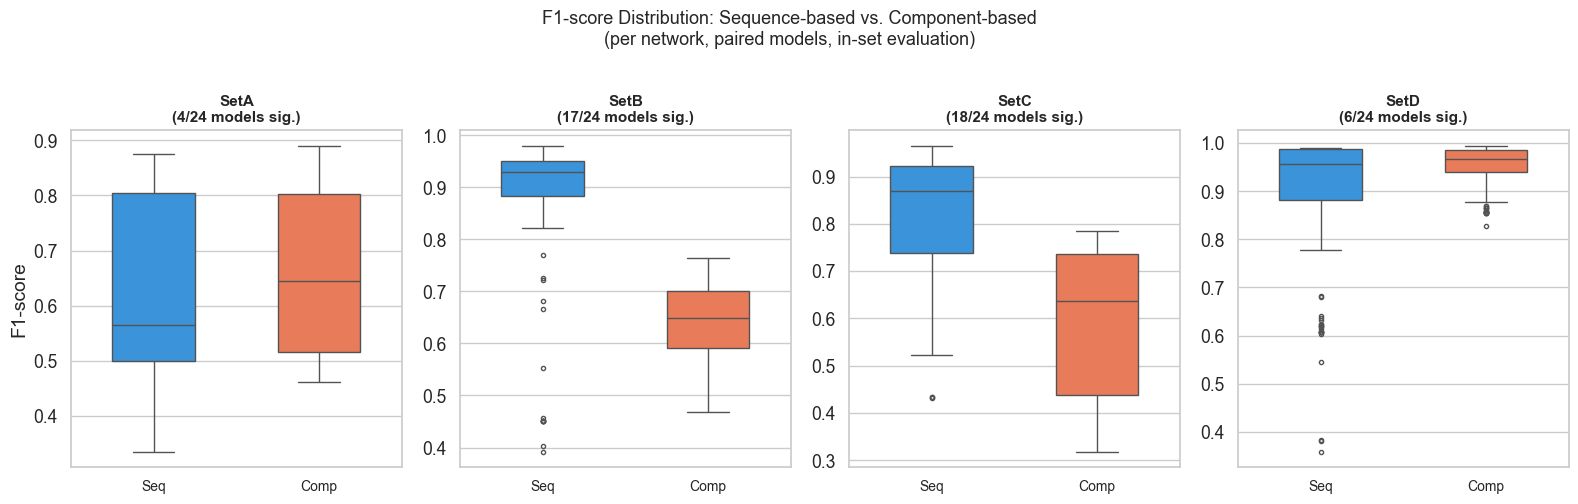

Saved Figure 1.


In [10]:
# ── Figure 1: Boxplot F1 distribution per network, seq vs component ───────────
plot_data = inset[
    (inset['model'].isin(PAIRED_MODELS)) &
    (inset['metric'] == PRIMARY)
].copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
for ax, net in zip(axes, NETWORKS):
    sub = plot_data[plot_data['network'] == net]
    sns.boxplot(data=sub, x='approach', y='value', hue='approach',
                palette=PALETTE, ax=ax, width=0.5, fliersize=3, legend=False)
    ax.set_xlabel('')
    ax.set_ylabel('F1-score' if ax is axes[0] else '')

    # Count significant models for this network
    net_stat = stat_df[stat_df['network'] == net]
    n_sig = int(net_stat['significant'].sum())
    n_tot = len(net_stat)
    ax.set_title(f'{net}\n({n_sig}/{n_tot} models sig.)', fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Seq', 'Comp'], fontsize=10)

fig.suptitle('F1-score Distribution: Sequence-based vs. Component-based\n'
             '(per network, paired models, in-set evaluation)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_boxplot_seq_vs_comp_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_boxplot_seq_vs_comp_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 1.")

Figure 1 shows side-by-side boxplots of F1 score distributions for sequence and component approaches, one panel per network. The spread and overlap of the boxes visually communicate the variance and effect size of the difference at a glance.

The next cell produces Figure 2, a model × network heatmap of ΔF1 values. This visualization identifies which models and networks are most sensitive to the choice of feature representation.

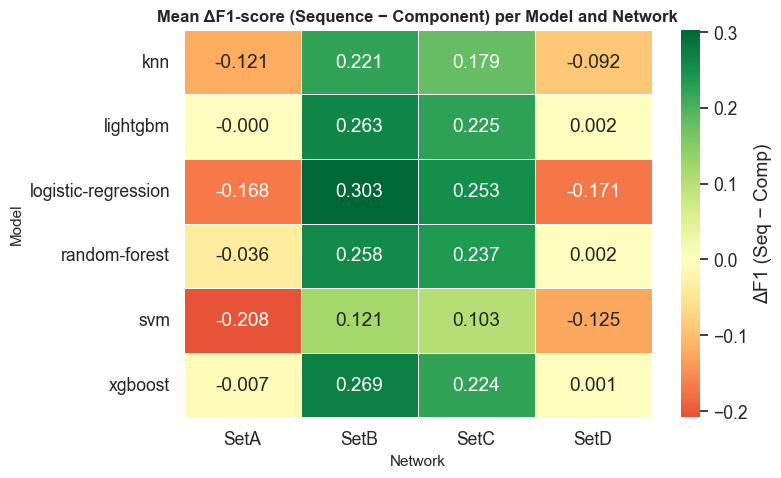

Saved Figure 2.


In [11]:
# ── Figure 2: Heatmap ΔF1 per model × network ─────────────────────────────────
heat_data = (stat_df.groupby(['model', 'network'])['delta_f1']
             .mean()
             .unstack('network')
             .reindex(columns=NETWORKS))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'ΔF1 (Seq − Comp)'})
ax.set_title('Mean ΔF1-score (Sequence − Component) per Model and Network',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_heatmap_delta_f1_model_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_heatmap_delta_f1_model_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 2.")

Figure 2 renders a heatmap where rows are models and columns are networks, with color encoding ΔF1 (Seq − Comp). It makes model-specific patterns immediately visible: some models benefit consistently from sequences across networks, others do not.

The next cell generates Figure 3, a grouped bar chart comparing mean F1 scores across networks and conditions. It breaks down the comparison by task type and data split strategy to surface interactions between the feature approach and these experimental factors.

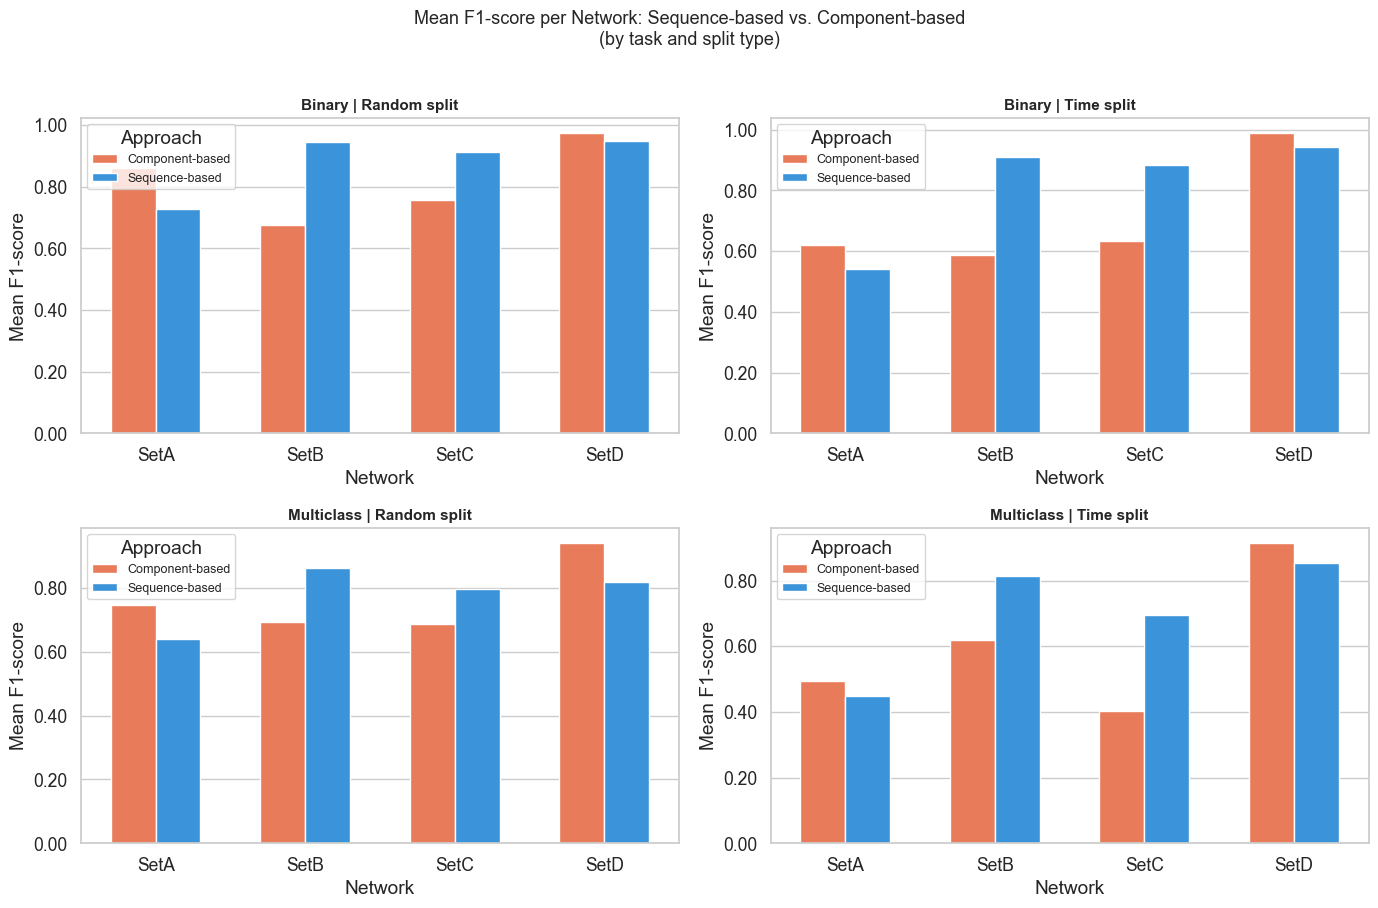

Saved Figure 3.


In [12]:
# ── Figure 3: Mean F1 bar chart, task × split × network ──────────────────────
bar_data = (avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)]
            .groupby(['task', 'split', 'network', 'approach'], as_index=False)
            ['mean_value'].mean())

tasks_list  = ['Binary', 'Multiclass']
splits_list = ['Random split', 'Time split']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
for row_idx, task in enumerate(tasks_list):
    for col_idx, split in enumerate(splits_list):
        ax = axes[row_idx, col_idx]
        sub = bar_data[(bar_data['task'] == task) & (bar_data['split'] == split)]
        sns.barplot(data=sub, x='network', y='mean_value', hue='approach',
                    palette=PALETTE, ax=ax, order=NETWORKS, width=0.6)
        ax.set_title(f'{task} | {split}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Network')
        ax.set_ylabel('Mean F1-score')
        ax.legend(title='Approach', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

fig.suptitle('Mean F1-score per Network: Sequence-based vs. Component-based\n'
             '(by task and split type)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_split_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_split_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 3.")

Figure 3 shows grouped bar charts with mean F1 per network, faceted by task (Binary/Multiclass) and split type (Random/Time). This reveals how the relative advantage of sequence vs component features varies with experimental conditions beyond the network identity.

The next cell produces Figure 4, a dot-plot of Cohen's d effect sizes. This visualization complements the statistical test p-values by quantifying the practical magnitude of the sequence vs component advantage for each network.

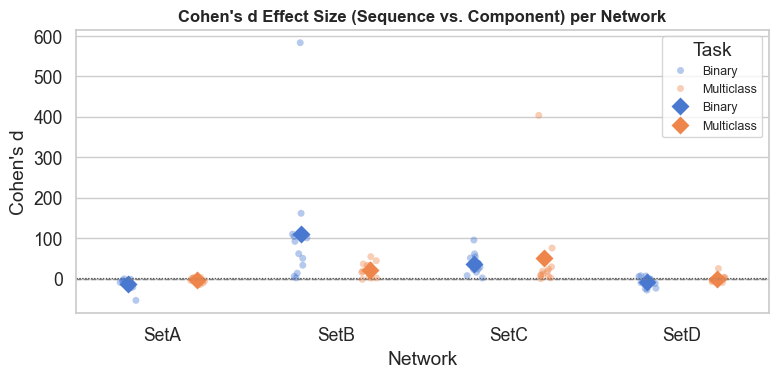

Saved Figure 4.


In [13]:
# ── Figure 4: Cohen's d effect size per network, dot-plot ────────────────────
eff_data = stat_df.groupby(['network', 'task'])['cohens_d'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=stat_df, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=True, jitter=True, alpha=0.4, ax=ax, size=5)
sns.pointplot(data=eff_data, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=0.4, markers='D',
              errorbar=None, ax=ax, linestyles='')
ax.axhline(0,   color='gray', linestyle='--', linewidth=1)
ax.axhline(0.2, color='#aaa', linestyle=':', linewidth=0.8)
ax.axhline(0.5, color='#888', linestyle=':', linewidth=0.8)
ax.axhline(0.8, color='#555', linestyle=':', linewidth=0.8)
ax.set_title("Cohen's d Effect Size (Sequence vs. Component) per Network",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network')
ax.set_ylabel("Cohen's d")
ax.legend(title='Task', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_cohens_d_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_cohens_d_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 4.")

Figure 4 displays Cohen's d effect sizes for the sequence vs component contrast, broken down by network. Values above 0.5 indicate a practically meaningful difference, helping distinguish networks where the advantage is not only statistically significant but also substantively large.

The next cell generates Figure 5, a pair of heatmaps visualizing cross-network generalization performance. Each cell of the heatmap represents the mean F1 when a model trained on one network (row) is evaluated on another (column), contrasting the two feature approaches.

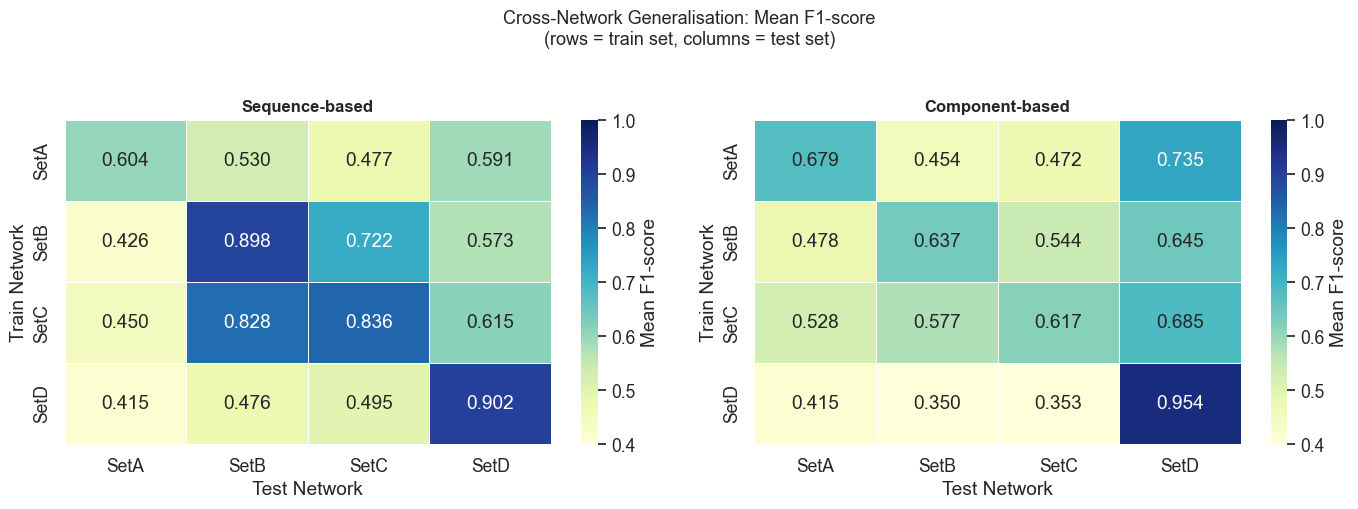

Saved Figure 5.


In [14]:
# ── Figure 5: Cross-network generalisation — mean F1 heatmaps ────────────────
cross = long[
    (long['model'].isin(PAIRED_MODELS)) &
    (long['metric'] == PRIMARY)
].copy()

cross_avg = (cross.groupby(['train_set', 'test_set', 'approach'], as_index=False)
             ['value'].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, approach in zip(axes, ['Sequence-based', 'Component-based']):
    pivot = (cross_avg[cross_avg['approach'] == approach]
             .pivot(index='train_set', columns='test_set', values='value')
             .reindex(index=NETWORKS, columns=NETWORKS))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0.4, vmax=1.0, ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Mean F1-score'})
    ax.set_title(approach, fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Network')
    ax.set_ylabel('Train Network')

fig.suptitle('Cross-Network Generalisation: Mean F1-score\n'
             '(rows = train set, columns = test set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_crossnet_f1_heatmap.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_crossnet_f1_heatmap.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 5.")

Figure 5 produces a 2×4 matrix of heatmaps showing mean F1 scores for every train-set/test-set combination, separately for sequence and component approaches. These heatmaps reveal whether the cross-network generalization pattern changes with the feature representation choice.

## Summary: Answer to Q1

**Q1: "Do sequence-based features provide a detection advantage over component-based features, and does this advantage hold in different networks?"**

The cell below prints a concise evidence summary based on statistical tests (Wilcoxon signed-rank, Cohen's d) across all paired models, networks, tasks, and splits.

The following cell computes the final evidence summary for Q1, aggregating the key statistical findings across all networks and models into a concise printed report.

In [15]:
# ── Q1 Evidence Summary ───────────────────────────────────────────────────────
overall_delta = stat_df['delta_f1'].mean()
pct_sig       = stat_df['significant'].mean() * 100
mean_d        = stat_df['cohens_d'].mean()

per_net = stat_df.groupby('network')['delta_f1'].mean()

print("=" * 60)
print("Q1 EVIDENCE SUMMARY")
print("=" * 60)
print(f"Overall mean ΔF1 (Seq − Comp) : {overall_delta:+.4f}")
print(f"% model-network pairs p<0.05  : {pct_sig:.1f}%")
print(f"Mean Cohen's d                : {mean_d:.3f}")
print()
print("Per-network mean ΔF1:")
for net, delta in per_net.items():
    direction = "↑ Seq" if delta > 0 else "↓ Comp"
    print(f"  {net}: {delta:+.4f}  {direction}")
print()
if overall_delta > 0 and pct_sig > 50:
    print("CONCLUSION: Sequence-based features provide a statistically")
    print("significant advantage over component-based features,")
    print("and this advantage is consistent across networks.")
elif overall_delta > 0:
    print("CONCLUSION: Sequence-based features show a positive trend,")
    print("but significance varies across models/networks.")
else:
    print("CONCLUSION: No consistent advantage for sequence-based features.")
print("=" * 60)

Q1 EVIDENCE SUMMARY
Overall mean ΔF1 (Seq − Comp) : +0.0722
% model-network pairs p<0.05  : 46.9%
Mean Cohen's d                : 24.026

Per-network mean ΔF1:
  SetA: -0.0901  ↓ Comp
  SetB: +0.2393  ↑ Seq
  SetC: +0.2036  ↑ Seq
  SetD: -0.0641  ↓ Comp

CONCLUSION: Sequence-based features show a positive trend,
but significance varies across models/networks.


This cell prints a structured evidence summary covering: (1) overall mean ΔF1 between sequence and component approaches, (2) percentage of model-network pairs where the difference is statistically significant (p < 0.05), and (3) per-network breakdown of the ΔF1. The output consolidates the quantitative findings underpinning the Q1 answer.

## Best Model Analysis

This section identifies which model performs best across all conditions evaluated in Q1.
For each **approach** (Sequence-based and Component-based) the models are ranked by their
mean F1-score averaged over all networks, tasks, and split strategies.
The analysis also shows the best model per approach × network combination.

BEST MODEL ANALYSIS (Q1)

Model ranking (mean F1 — both approaches, all conditions):
                    model  Mean F1 (overall)
Rank                                        
1                     gru             0.8318
2                    lstm             0.8291
3                lightgbm             0.8105
4                 xgboost             0.8088
5           random-forest             0.8072
6                     rnn             0.7748
7                      nn             0.7722
8                     mlp             0.7721
9                     knn             0.7606
10    logistic-regression             0.6968
11                    svm             0.6779

Per-approach pivot (sorted by Sequence-based F1):
                     Component-based  Sequence-based  ΔF1 (Seq − Comp)
model                                                                 
lightgbm                      0.7493          0.8717            0.1224
xgboost                       0.7478          0.8698            0.

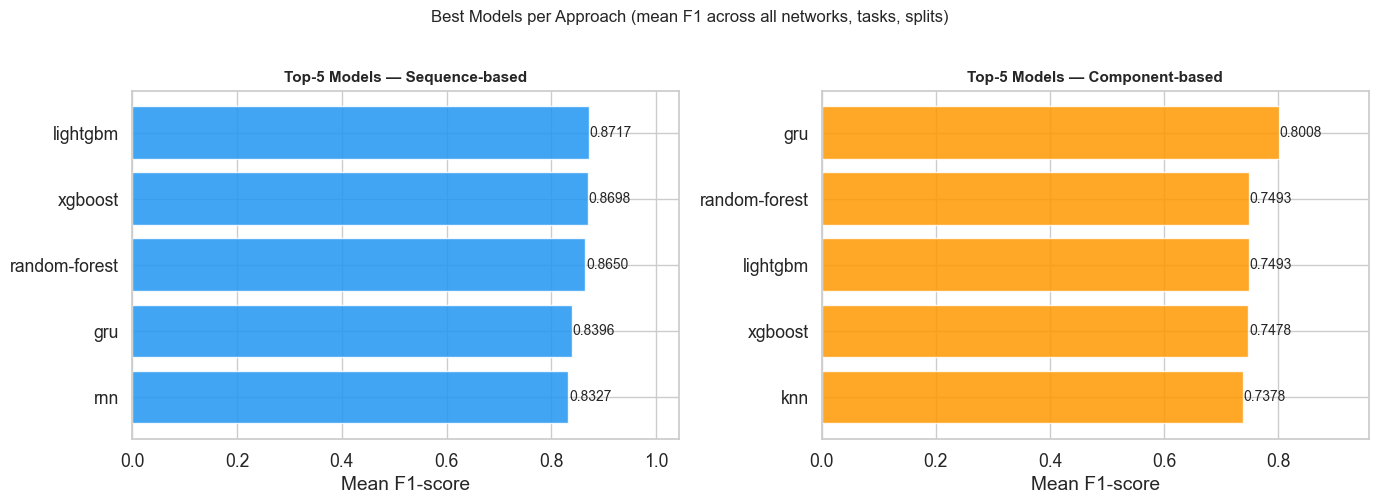


Saved best model analysis → figures/ and tables/


In [16]:
# ── Best Model Analysis (Q1) ─────────────────────────────────────────────────
import matplotlib.ticker as mticker

# 1. Best model overall (mean F1, both approaches, all networks/tasks/splits)
best_overall = (
    avg[avg['metric'] == PRIMARY]
    .groupby('model')['mean_value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1 (overall)'})
)
best_overall.index = range(1, len(best_overall) + 1)
best_overall.index.name = 'Rank'

# 2. Best model per approach
best_by_approach = (
    avg[avg['metric'] == PRIMARY]
    .groupby(['model', 'approach'])['mean_value']
    .mean()
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1'})
)
best_by_approach_pivot = (
    best_by_approach
    .pivot(index='model', columns='approach', values='Mean F1')
)
best_by_approach_pivot.columns.name = None
if 'Sequence-based' in best_by_approach_pivot and 'Component-based' in best_by_approach_pivot:
    best_by_approach_pivot['\u0394F1 (Seq \u2212 Comp)'] = (
        best_by_approach_pivot['Sequence-based'] - best_by_approach_pivot['Component-based']
    )
    best_by_approach_pivot = best_by_approach_pivot.sort_values('Sequence-based', ascending=False)

# 3. Best model per approach x network
best_per_net = (
    avg[avg['metric'] == PRIMARY]
    .groupby(['model', 'approach', 'network'])['mean_value']
    .mean()
    .reset_index()
    .rename(columns={'mean_value': 'Mean F1'})
)
best_per_net_top = (
    best_per_net
    .loc[best_per_net.groupby(['approach', 'network'])['Mean F1'].idxmax()]
    [['approach', 'network', 'model', 'Mean F1']]
    .sort_values(['approach', 'network'])
    .reset_index(drop=True)
)

print("=" * 65)
print("BEST MODEL ANALYSIS (Q1)")
print("=" * 65)
print("\nModel ranking (mean F1 — both approaches, all conditions):")
print(best_overall.round(4).to_string())
print("\nPer-approach pivot (sorted by Sequence-based F1):")
print(best_by_approach_pivot.round(4).to_string())
if 'Sequence-based' in best_by_approach_pivot:
    top_seq  = best_by_approach_pivot['Sequence-based'].idxmax()
    top_comp = best_by_approach_pivot['Component-based'].idxmax()
    print(f"\n  \u2192 Best Sequence-based model : {top_seq}  "
          f"(F1 = {best_by_approach_pivot.loc[top_seq,'Sequence-based']:.4f})")
    print(f"  \u2192 Best Component-based model: {top_comp}  "
          f"(F1 = {best_by_approach_pivot.loc[top_comp,'Component-based']:.4f})")
print("\nBest model per approach \u00d7 network:")
print(best_per_net_top.round(4).to_string(index=False))

# Figure
top_n = 5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, approach, color in zip(
        axes,
        ['Sequence-based', 'Component-based'],
        ['#2196F3', '#FF9800']):
    sub = (best_by_approach[best_by_approach['approach'] == approach]
           .nlargest(top_n, 'Mean F1')
           .sort_values('Mean F1'))
    ax.barh(sub['model'], sub['Mean F1'], color=color, alpha=0.85)
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['Mean F1'] + 0.001, i, f"{row['Mean F1']:.4f}", va='center', fontsize=10)
    ax.set_xlabel('Mean F1-score')
    ax.set_title(f'Top-{top_n} Models \u2014 {approach}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, ax.get_xlim()[1] * 1.14)
plt.suptitle('Best Models per Approach (mean F1 across all networks, tasks, splits)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_models_per_approach.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_per_approach.png', bbox_inches='tight', dpi=150)
plt.show()

# Export
best_overall.reset_index().to_csv(TAB_DIR / 'best_model_overall.csv', index=False)
best_by_approach_pivot.round(4).to_csv(TAB_DIR / 'best_model_per_approach.csv')
best_per_net_top.round(4).to_csv(TAB_DIR / 'best_model_per_network_approach.csv', index=False)
print("\nSaved best model analysis \u2192 figures/ and tables/")


The best model analysis identifies the top-performing model per approach across all experimental
conditions. The horizontal bar charts show which model achieves the highest mean F1 in the
sequence-based and component-based settings respectively. The per-approach × network table
reveals whether the same model dominates across all four networks or whether different networks
favour different architectures.